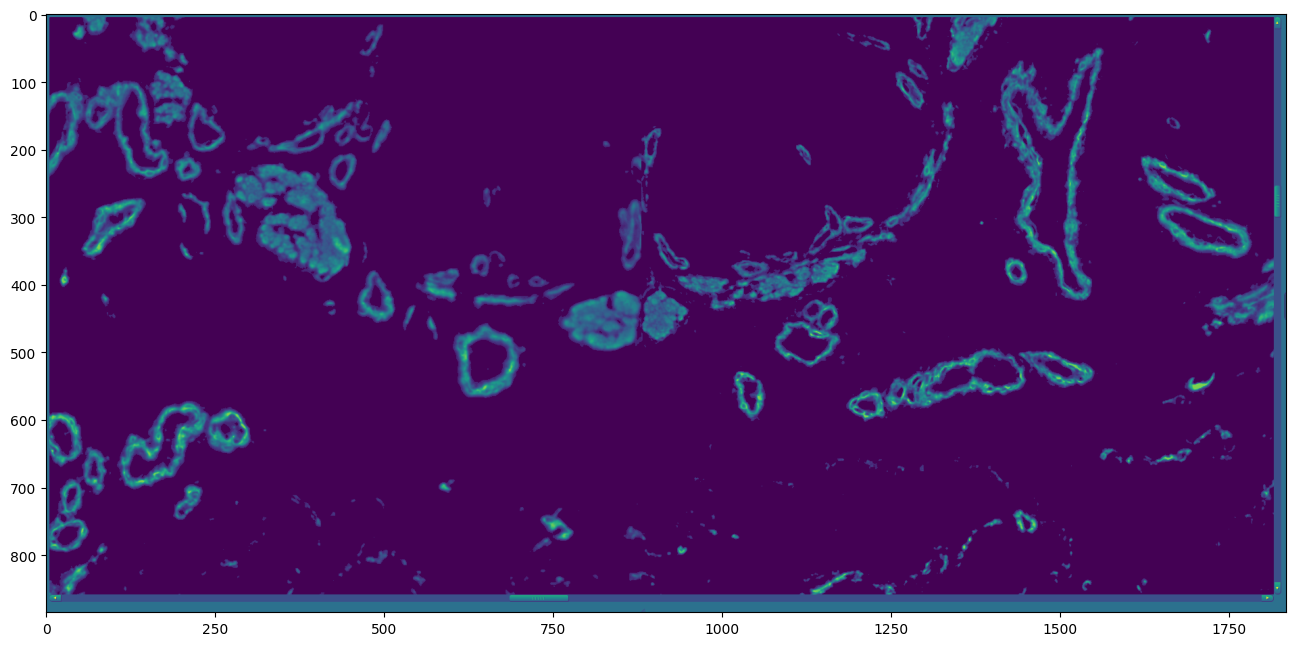

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Image4.png', cv2.IMREAD_GRAYSCALE)

_,ax = plt.subplots(1,1,figsize = (16,16))
plt.imshow(img)
plt.show()



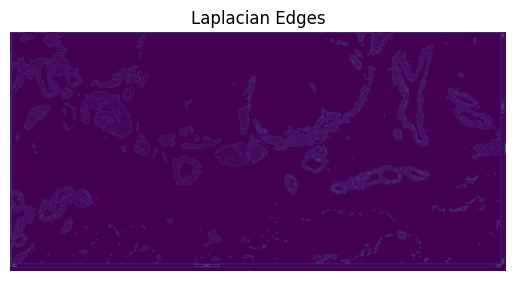

In [36]:
laplace = cv2.Laplacian(img, cv2.CV_64F)
laplace = cv2.convertScaleAbs(laplace)

plt.imshow(laplace)
plt.title("Laplacian Edges")
plt.axis('off')
plt.show()


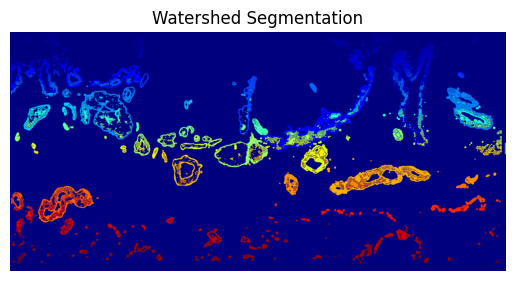

In [104]:
# Convert to binary using Otsu threshold
_, thresh = cv2.threshold(laplace, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Distance transform
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.2 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Background region
kernel = np.ones((3,3), np.uint8)
sure_bg = cv2.dilate(thresh, kernel, iterations=3)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

# Watershed
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
markers = cv2.watershed(img_color, markers)

# Visualize
plt.imshow(markers, cmap='jet')
plt.title("Watershed Segmentation")
plt.axis('off')
plt.show()

In [107]:
# Refining the watershed model using fourier descriptors
contour_list = list()
length_list = list()

MAX_LEN = 3000 # gets rid of entire picture level contour (no reason as to the exact number)
MIN_LEN = 20 #placeholder for now

for label in np.unique(markers):
    if label == -1 or label == 1:
        continue

    mask = np.zeros_like(markers, dtype=np.uint8)
    mask[markers == label] = 255

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        continue
    contour = contours[0]

    contour_complex = np.empty(contour.shape[0], dtype=complex)
    for i in range(contour.shape[0]):
        contour_complex[i] = complex(contour[i][0][0], contour[i][0][1])

    fourier_result = np.fft.fft(contour_complex)
    n_descriptors = 50
    fourier_result[n_descriptors:-n_descriptors] = 0
    contour_reconstructed = np.fft.ifft(fourier_result)

    contour_reconstructed = np.array([[int(pt.real), int(pt.imag)] for pt in contour_reconstructed], dtype=np.int32)
    
    if len(contour_reconstructed) < MAX_LEN and len(contour_reconstructed) > MIN_LEN:
        contour_list.append(contour_reconstructed)
        length_list.append(len(contour_reconstructed))
        cv2.drawContours(img_color, [contour_reconstructed], -1, (0, 255, 0), 2)

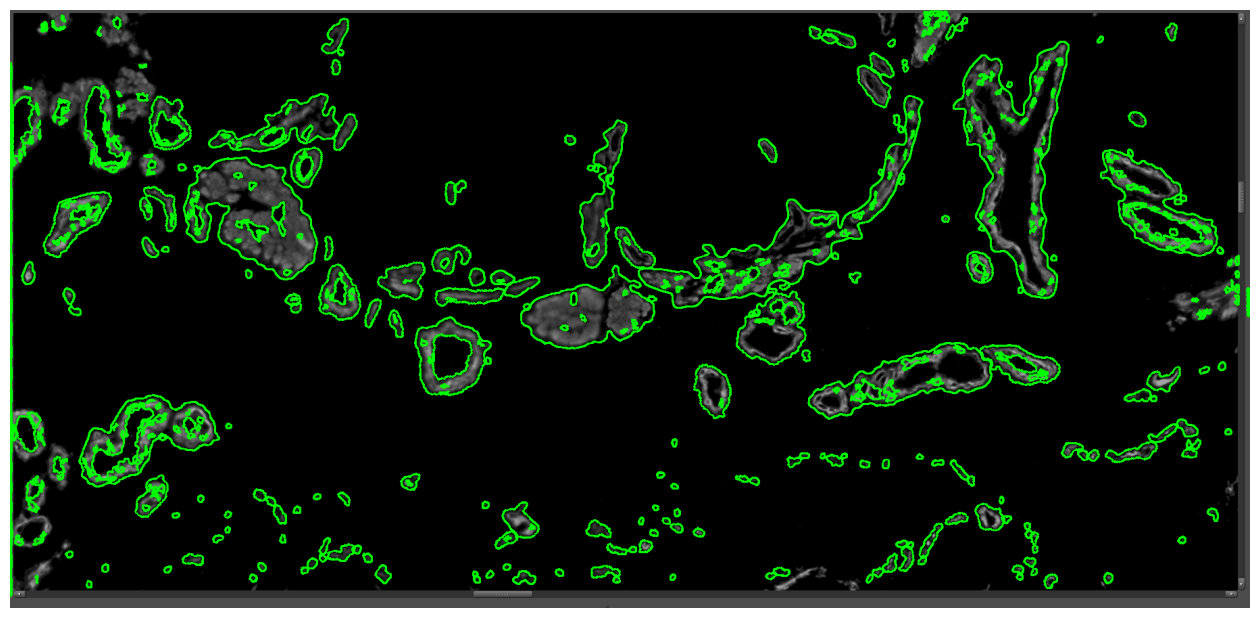

In [108]:

_,ax = plt.subplots(1,1,figsize = (16,16))
plt.imshow(img_color)
plt.axis('off')
plt.show()

In [109]:
length_list, contour_list = zip(*sorted(zip(length_list,contour_list),key = lambda x: x[0], reverse=True)) # sorts both by length
img_color = cv2.imread('Image4.png', cv2.IMREAD_COLOR_RGB) # to refresh (new image to draw on)

# Under assumption that the outermost contour is going to be the largest (not always true, but we are going to assume)
outer_contour_list = list()

for i in range(len(length_list)):
    redundant = False

    if len(outer_contour_list) == 0:
        cv2.drawContours(img_color, [contour_list[i]], -1, (0, 255, 0), 2)
        outer_contour_list.append(contour_list[i])
        
    else:
        

        for contour in outer_contour_list:
            for point in contour_list[i]:
                if cv2.pointPolygonTest(contour,[int(point[0]), int(point[1])],False) != -1: # if all points lie completely outside,  we accept
                    redundant = True
                    break
            if redundant:
                break

        if not redundant:
            cv2.drawContours(img_color, [contour_list[i]], -1, (0, 255, 0), 2)
            outer_contour_list.append(contour_list[i])


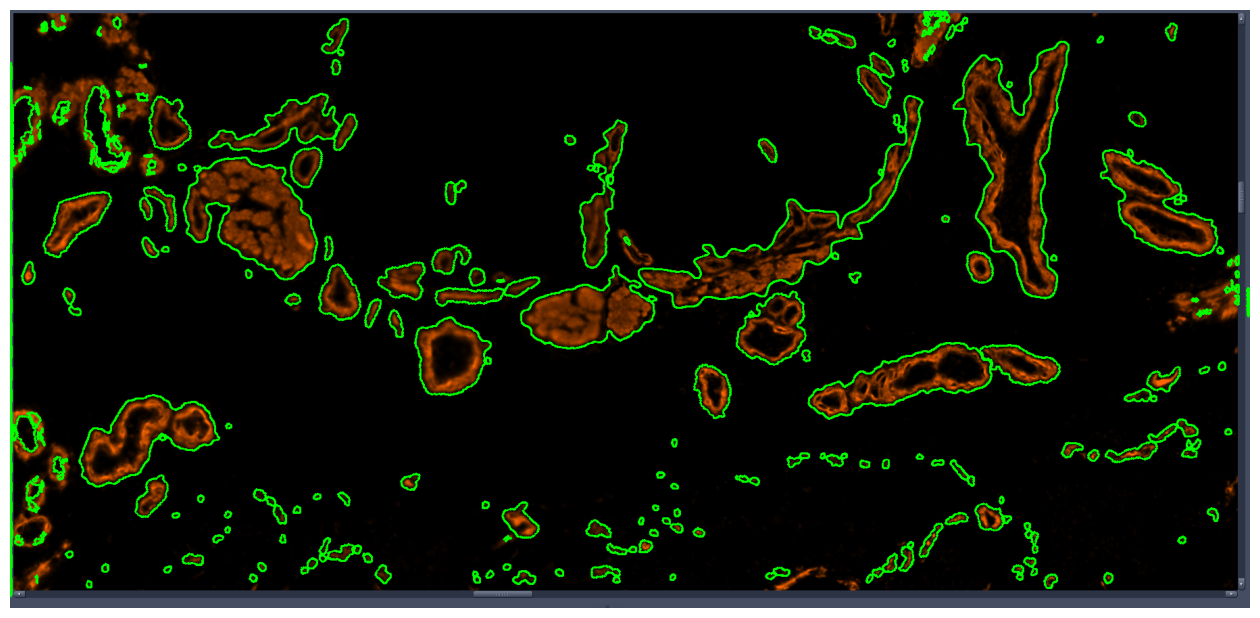

In [110]:
img_overlay = img_color.copy()



_,ax = plt.subplots(1,1,figsize = (16,16))
plt.imshow(img_overlay)
plt.axis('off')
plt.show()

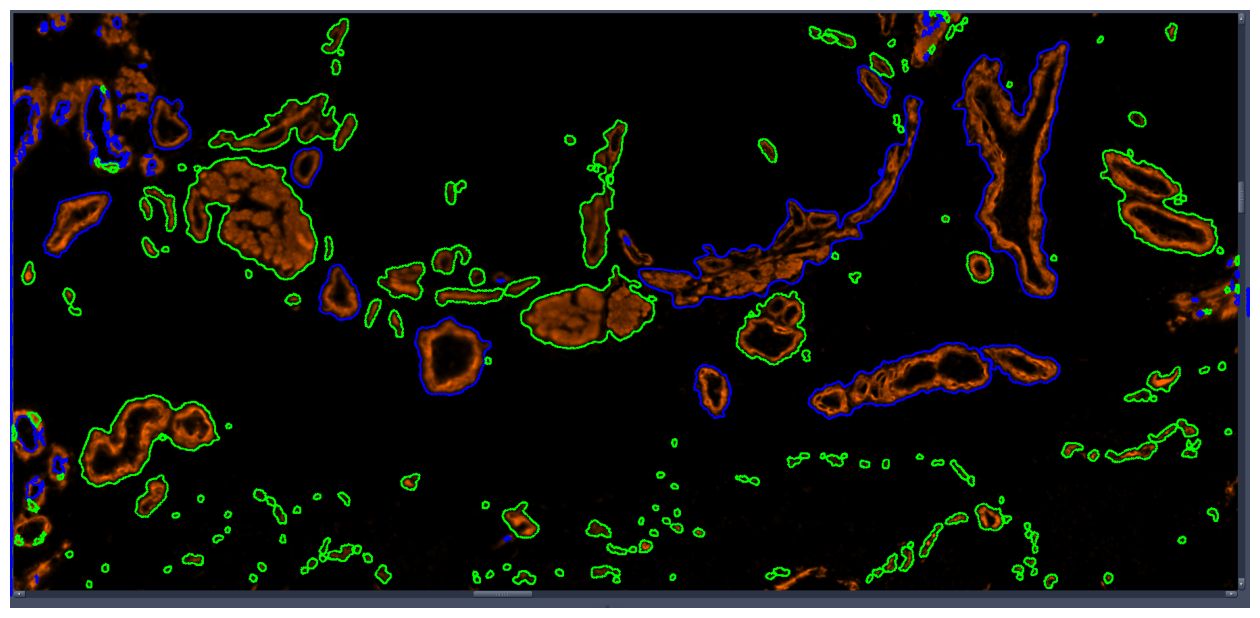

In [93]:
def classify_shape(contour, gray_img, ring_threshold=0.70, erode_fraction=0.4):
    """
    Compares center intensity to overall mean inside the contour.
    ring_threshold: if center_mean < threshold * overall_mean → ring
    """
    filled = np.zeros(gray_img.shape, dtype=np.uint8)
    cv2.fillPoly(filled, [contour], 255)

    # Scale erosion to structure size (so small and large shapes are treated equally)
    eq_radius = np.sqrt(cv2.contourArea(contour) / np.pi)
    n_iters = max(2, int(eq_radius * erode_fraction))

    kernel = np.ones((3, 3), np.uint8)
    center_mask = cv2.erode(filled, kernel, iterations=n_iters)

    if center_mask.sum() == 0:
        # Eroded to nothing → walls were thin → ring
        return 'ring'

    center_mean = np.mean(gray_img[center_mask == 255])
    overall_mean = np.mean(gray_img[filled == 255])

    return 'ring' if center_mean < ring_threshold * overall_mean else 'solid'


fresh_overlay = cv2.imread("Image4.png", cv2.IMREAD_COLOR_RGB)

for contour in outer_contour_list:
    label = classify_shape(contour, img)
    color = (0, 0, 255) if label == 'ring' else (0, 255, 0)  # orange vs green
    cv2.drawContours(fresh_overlay, [contour], -1, color, 2)

plt.figure(figsize=(16,16))
plt.imshow(fresh_overlay)
plt.axis('off')
plt.show()



ratios = []
for contour in outer_contour_list:
    filled = np.zeros(img.shape, dtype=np.uint8)
    cv2.fillPoly(filled, [contour], 255)
    eq_radius = np.sqrt(cv2.contourArea(contour) / np.pi)
    n_iters = max(2, int(eq_radius * 0.4))
    center = cv2.erode(filled, np.ones((3,3), np.uint8), iterations=n_iters)
    if center.sum() > 0:
        ratios.append(np.mean(img[center == 255]) / np.mean(img[filled == 255]))
    else:
        ratios.append(0.0)





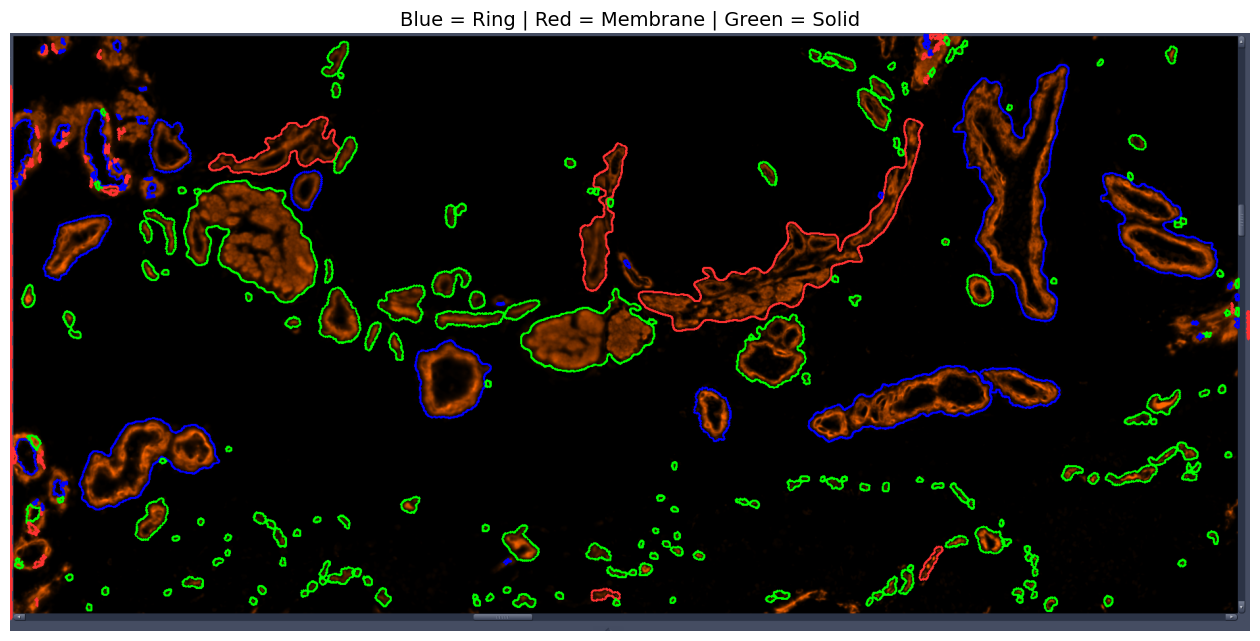

Rings: 48  |  Membranes: 44  |  Solids: 181


In [97]:
fresh_overlay = cv2.imread("Image4.png", cv2.IMREAD_COLOR_RGB)

def classify_contour(contour, gray_img):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    
    if perimeter == 0:
        return 'unknown'
    
    circularity = (4 * np.pi * area) / (perimeter ** 2)

    # Check center darkness to distinguish ring from solid blob
    if circularity > 0.25:
        filled = np.zeros(gray_img.shape, dtype=np.uint8)
        cv2.fillPoly(filled, [contour], 255)
        eq_radius = np.sqrt(area / np.pi)
        n_iters = max(2, int(eq_radius * 0.35))
        center_mask = cv2.erode(filled, np.ones((3,3), np.uint8), iterations=n_iters)

        if center_mask.sum() > 0:
            center_mean = np.mean(gray_img[center_mask == 255])
            overall_mean = np.mean(gray_img[filled == 255])
            ratio = center_mean / overall_mean if overall_mean > 0 else 1.0
        else:
            ratio = 0.0  # eroded to nothing = thin walls = ring

        if ratio < 0.65:
            return 'ring'
        else:
            return 'solid'
    else:
        return 'membrane'

# Colour scheme:
# Blue   (0, 0, 255)   → ring structures
# Red    (255, 50, 50) → elongated membranes
# Green  (0, 255, 0)   → solid blobs

counts = {'ring': 0, 'membrane': 0, 'solid': 0}
colour_map = {
    'ring':     (0,   0,   255),
    'membrane': (255, 50,  50),
    'solid':    (0,   255, 0),
}

for contour in outer_contour_list:
    label = classify_contour(contour, img)
    counts[label] += 1
    cv2.drawContours(fresh_overlay, [contour], -1, colour_map[label], 2)

# Legend overlay



_, ax = plt.subplots(1, 1, figsize=(16, 16))
plt.imshow(fresh_overlay)
plt.axis('off')
plt.title("Blue = Ring | Red = Membrane | Green = Solid", fontsize=14)
plt.show()

print(f"Rings: {counts['ring']}  |  Membranes: {counts['membrane']}  |  Solids: {counts['solid']}")


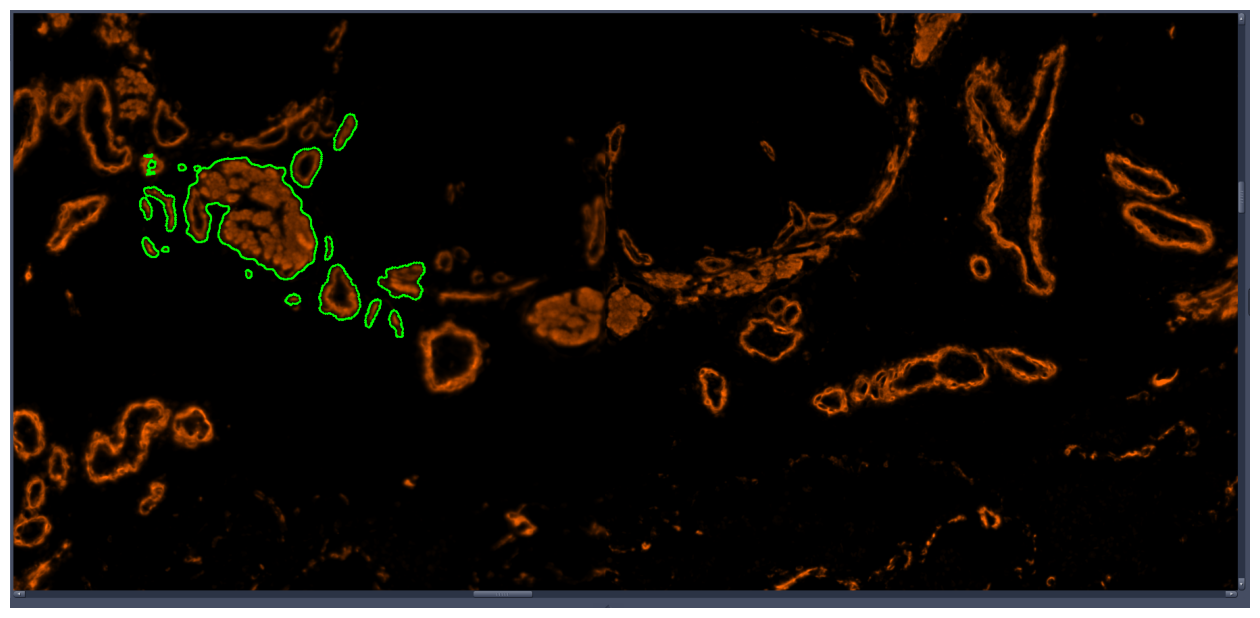

In [92]:
tl = (189,148)
br = (597,468)

selected_contours = []
for con in outer_contour_list:
    if tl[0] <= con[0][0] <= br[0]:
        if tl[1] <= con[0][1] <= br[1]:
            selected_contours.append(con)

fresh_overlay = cv2.imread("Image4.png",cv2.IMREAD_COLOR_RGB)
cv2.drawContours(fresh_overlay, selected_contours, -1, (0, 255, 0), 2)
_,ax = plt.subplots(1,1,figsize = (16,16))
plt.imshow(fresh_overlay)
plt.axis('off')
plt.show()

In [53]:
print(selected_contours[0])

[[345 219]
 [343 219]
 [342 220]
 ...
 [348 219]
 [347 219]
 [346 219]]


In [43]:
import cv2
import numpy as np
import pandas as pd




def fill_mask(contour, image_shape):
    mask = np.zeros(image_shape, dtype=np.uint8)
    cv2.fillPoly(mask, [contour], 255)
    return mask


In [85]:
def iou(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / union

contour_df = pd.read_csv("orange_gt.csv")
# contour_df = contour_df[contour_df['contour_id'] == 0].drop(columns=["contour_id","colour"])
# contour_arr = np.array(contour_df)


gt_mask = np.zeros_like(img)
pred_mask = np.zeros_like(img)

for i in contour_df["contour_id"].unique():
    current_contour = contour_df[contour_df['contour_id'] == i].drop(columns=["contour_id","colour"])
    current_mask = fill_mask(np.array(current_contour), img.shape)
    gt_mask = np.logical_or(gt_mask,current_mask)

for i in range(len(selected_contours)):
    current_mask = fill_mask(np.array(selected_contours[i]), img.shape)
    pred_mask = np.logical_or(pred_mask,current_mask)


print("IoU:", iou(pred_mask, gt_mask))

IoU: 0.5951665756417258


In [86]:
def dice(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    return 2 * intersection / (pred.sum() + gt.sum())
print("Dice Coefficient:", dice(pred_mask, gt_mask))

Dice Coefficient: 0.7462124454335359
